In [1]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import glob

def make_combination(config_dict):
    keys, values = zip(*config_dict.items())
    return [dict(zip(keys, v)) for v in itertools.product(*values)]

In [2]:
UEA_MTSC30 = ['EthanolConcentration',
              'FaceDetection',
              'Handwriting',
              'Heartbeat',
              'JapaneseVowels',
              'PEMS-SF',
              'SelfRegulationSCP1',
              'SelfRegulationSCP2',
              'SpokenArabicDigits',
              'UWaveGestureLibrary',
              'ArticularyWordRecognition',
              'AtrialFibrillation',
              'BasicMotions',
              'CharacterTrajectories',
              'Cricket',
              'DuckDuckGeese',
              'EigenWorms',
              'Epilepsy',
              'ERing',
              'FingerMovements',
              'HandMovementDirection',
              'InsectWingbeat',
              'Libras',
              'LSST',
              'MotorImagery',
              'NATOPS',
              'PenDigits',
              'PhonemeSpectra',
              'RacketSports',
              'StandWalkJump']

In [3]:
from omegaconf import OmegaConf
data_info = OmegaConf.load(f"../data_classification.yaml")

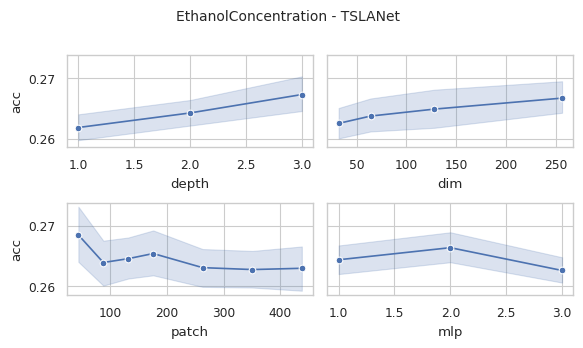

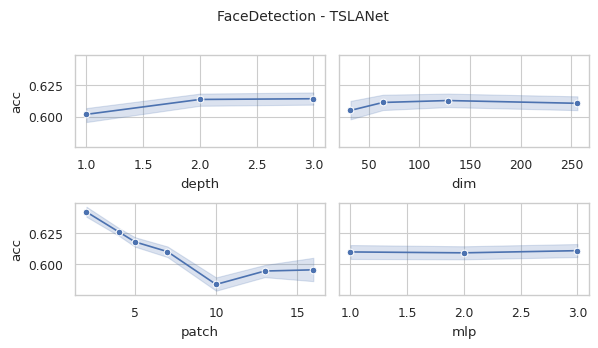

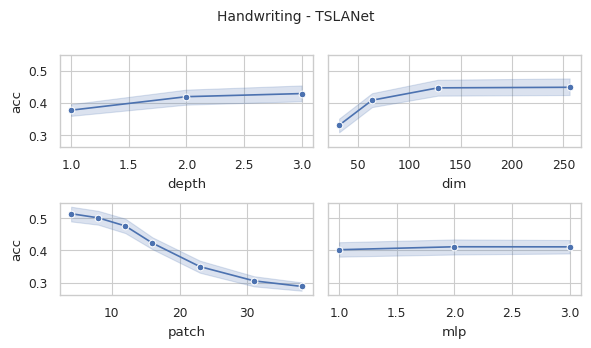

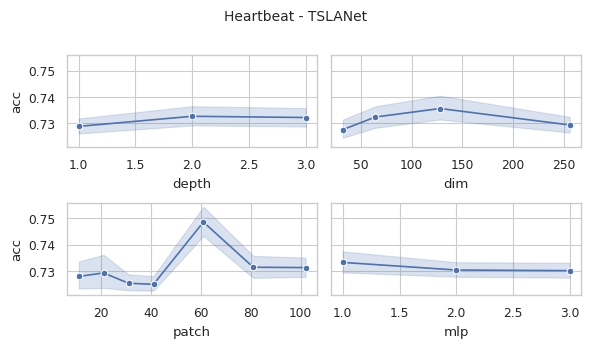

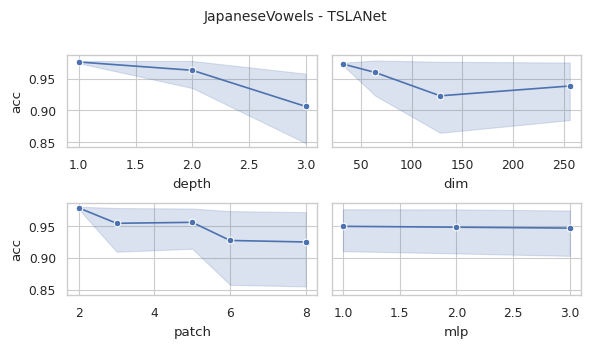

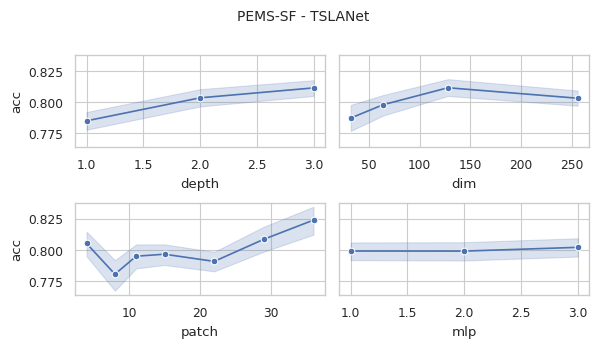

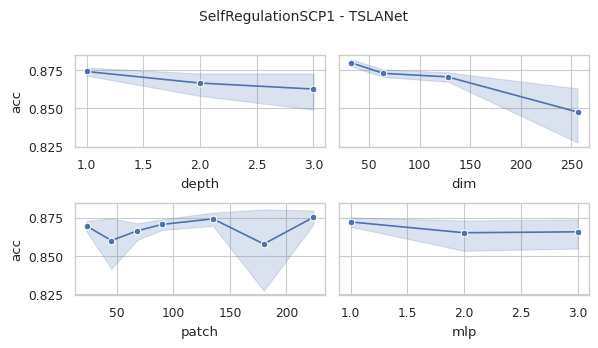

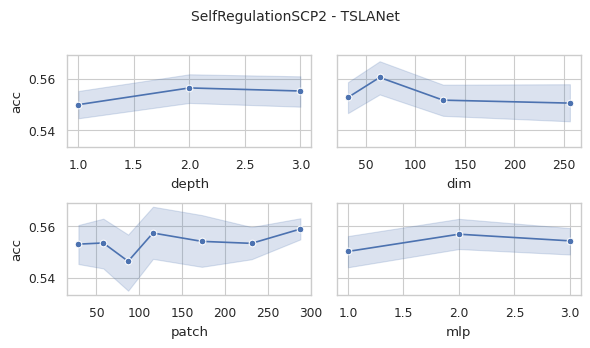

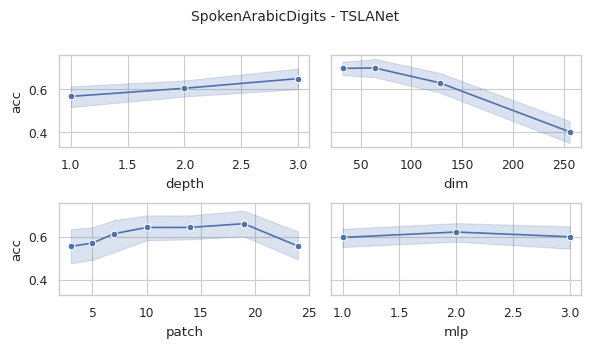

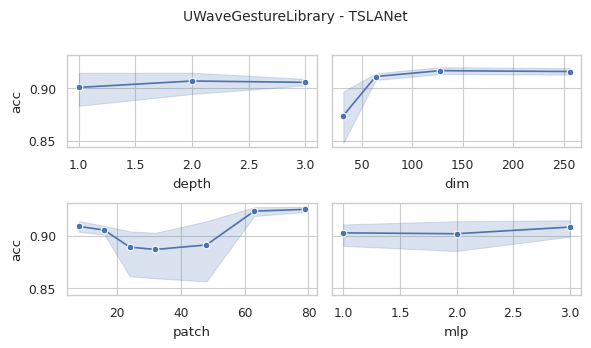

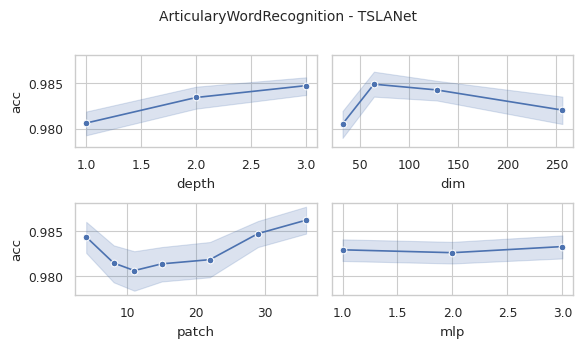

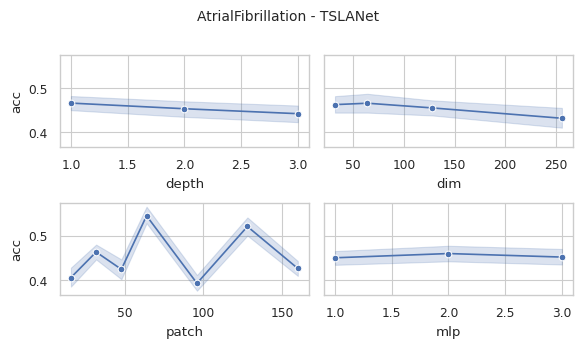

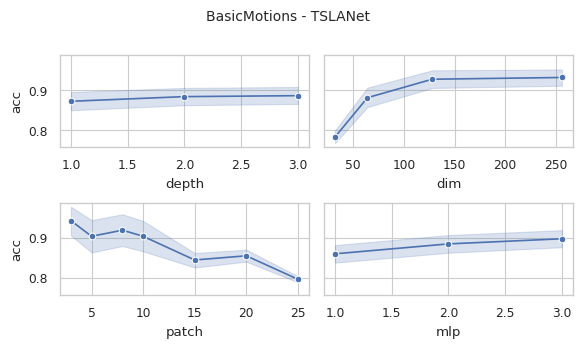

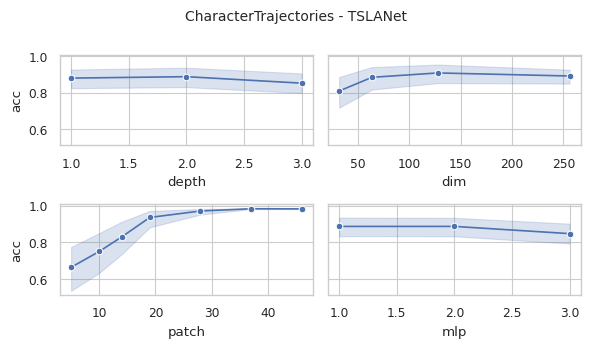

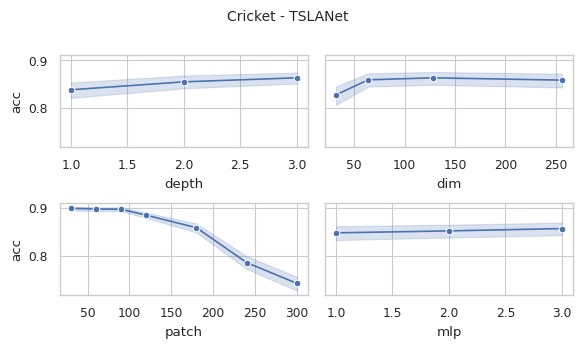

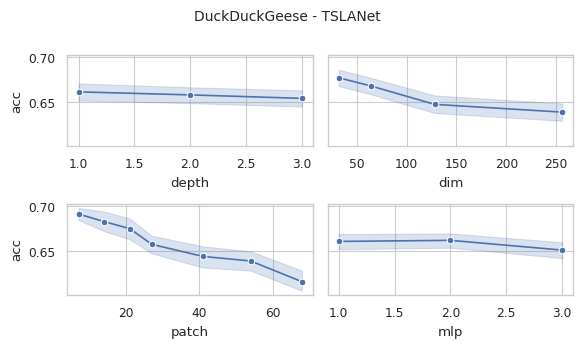

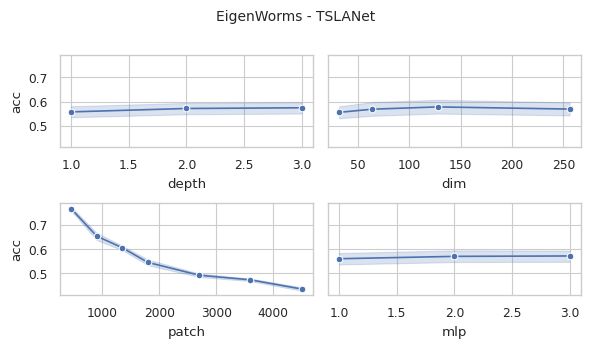

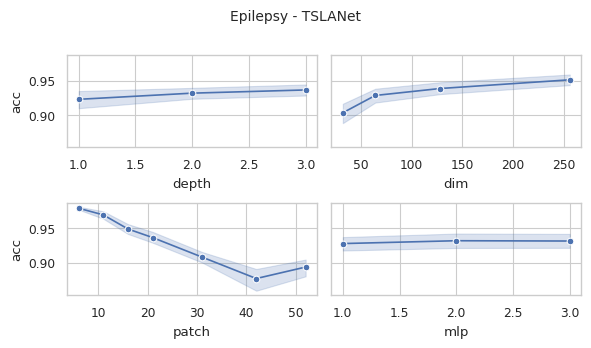

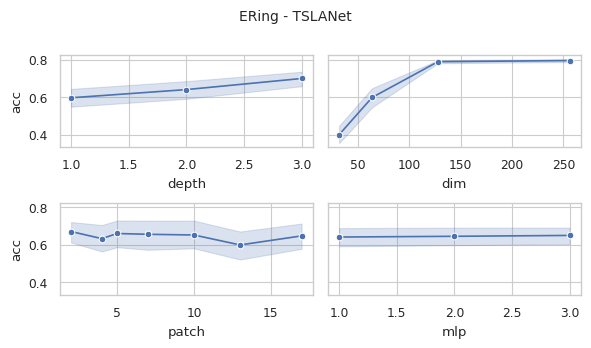

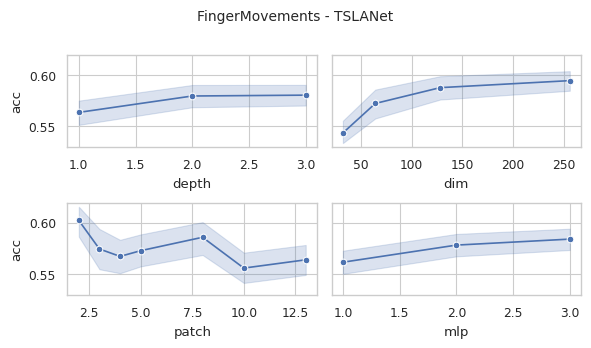

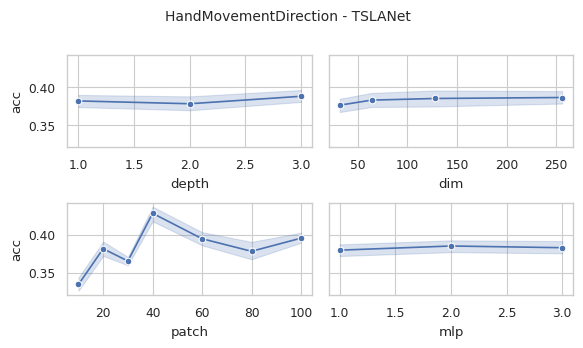

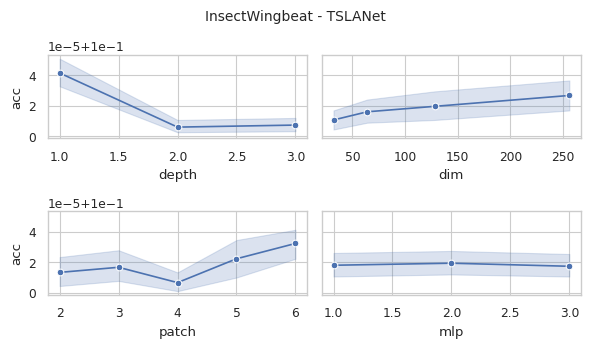

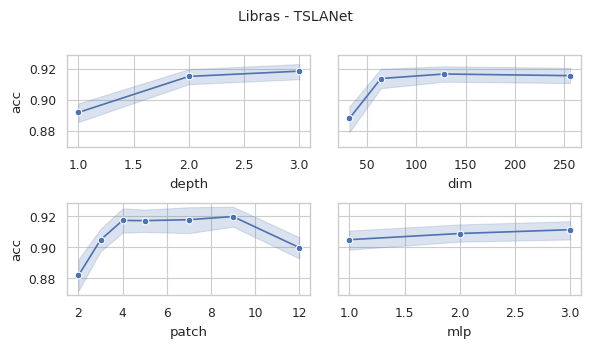

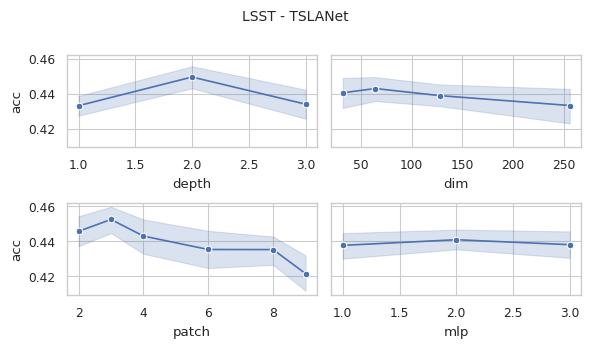

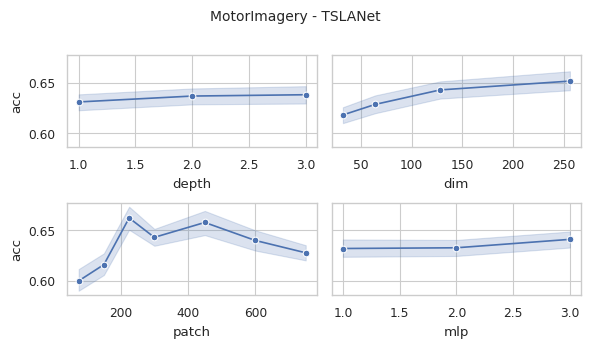

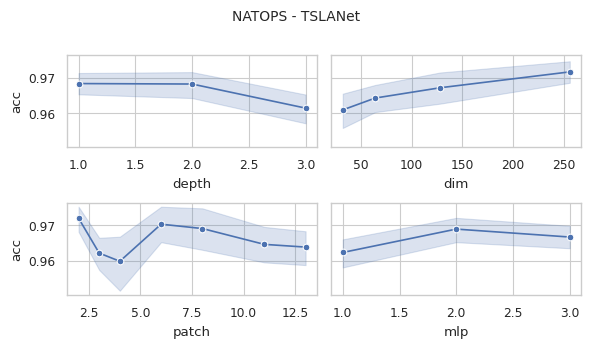

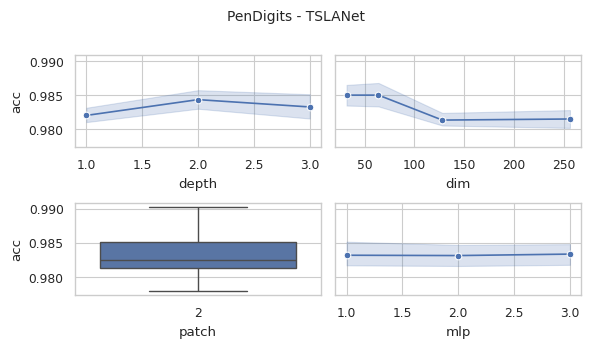

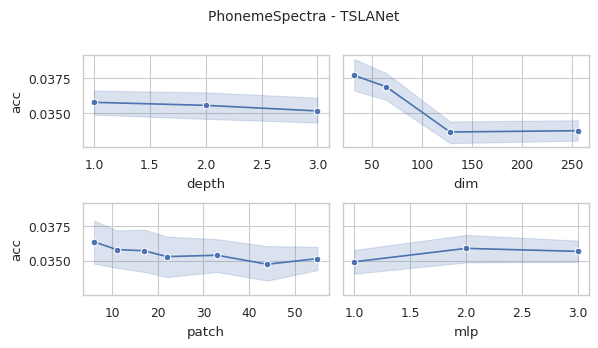

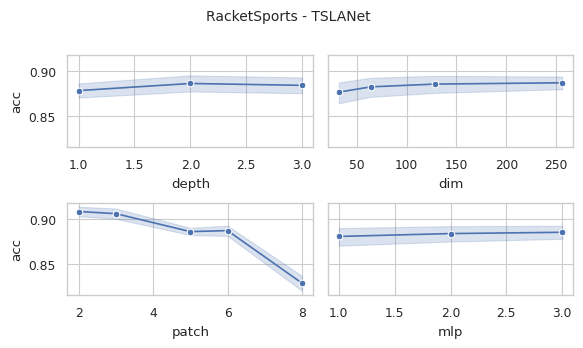

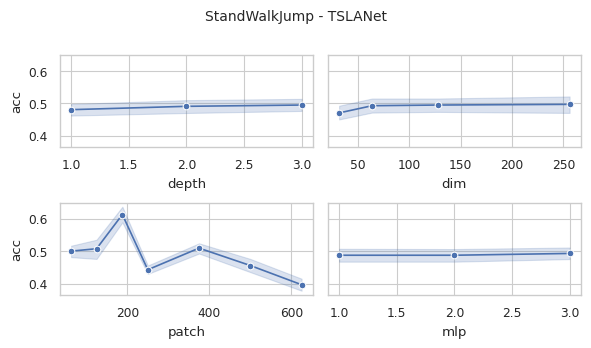

In [7]:
model = 'TSLANet'
result_dict = dict()

for data_name in UEA_MTSC30:
    
    # if os.path.exists(f'../03-full_results/{model}/textFiles/CLS_{data_name}.txt'):
    #     with open(f'../03-full_results/{model}/textFiles/CLS_{data_name}.txt', 'r') as file:
    if os.path.exists(f'../../textFiles/CLS_{data_name}.txt'):
        with open(f'../../textFiles/CLS_{data_name}.txt', 'r') as file:
            data = file.read().splitlines()
    else:
        print('no file')
        continue

    result_lst = list()
    for i in range(len(data)):
        if data[i].startswith(data_name):
            data_meta = list(filter(lambda x: x != '', data[i].strip().split('_')))
            data_meta[1] = int(data_meta[1].replace('dim', ''))
            data_meta[2] = int(data_meta[2].replace('depth', ''))
            data_meta[3] = float(data_meta[3].replace('mask', ''))
            data_meta[4] = int(data_meta[4].replace('patch', ''))
            data_meta[5] = float(data_meta[5].replace('mlp', ''))
            data_meta[7] = (data_meta[7] == 'True')
            data_meta[9] = (data_meta[9] == 'True')
            data_meta[11] = (data_meta[11] == 'True')
            data_meta[13] = (data_meta[13] == 'True')

            acc = eval(data[i+2].split('acc:')[1].split(', mf1:')[0])

            ckpt_path = glob.glob('/data/user/MambaSL/logs (TSLANet)/{}/epoch=*.ckpt'.format(data[i].strip()))
            if len(ckpt_path) == 0:
                print('no ckpt')
                continue
            else:
                ckpt_path = ckpt_path[0]
            
            result_data = {
                'data_name': data_meta[0],
                'dim': data_meta[1],
                'depth': data_meta[2],
                'mask': data_meta[3],
                'patch': data_meta[4],
                'mlp': data_meta[5],
                'ASB': data_meta[7],
                'AF': data_meta[9],
                'ICB': data_meta[11],
                'preTr': data_meta[13],
                'acc': acc['test'],
                'acc_val': acc['val'],
                'model_size (KB)': os.path.getsize(ckpt_path) / 1024,
                'log_path': data[i].strip(),
            }

            result_lst.append(result_data)

    result_df = pd.DataFrame(result_lst)
    os.makedirs(f'./{model}', exist_ok=True)
    result_df.to_csv(f'./{model}/{data_name}.csv', index=False)
    result_dict[data_name] = result_df.copy()

    cols = ['depth', 'dim', 'patch', 'mlp']
    num_cols, num_rows = 2, 2
    
    # # Boxplot
    # sns.set_theme(style="whitegrid")
    # sns.set_context("paper", font_scale=1)
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(6, 3.5), sharey=True)
    # for i, col in enumerate(cols):
    #     sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i%num_cols], legend=False)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)

    # Lineplot
    sns.set_theme(style="whitegrid")
    sns.set_context("paper", font_scale=1)
    fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(6, 3.5), sharey=True)
    for i, col in enumerate(cols):
        if result_df[col].unique().size == 1: 
            sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i//num_cols][i%num_cols], legend=False)
        else:
            sns.lineplot(x=col, y='acc', data=result_df, ax=axs[i//num_cols][i%num_cols], legend=False, style='data_name', markers=True)
    fig.suptitle(f'{data_name} - {model}', fontsize=10)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    display(fig)
    plt.savefig(f'./{model}/{data_name}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)

    # print(f'{data_name} - {model} : {result_df["acc"].max()*100:.14f} ({len(result_df)})')
    
    

    # # Lineplot where each line represents same hyperparameter combination except one
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(6, 3.5), sharey=True)
    # for i, col in enumerate(cols):
    #     col_rest = [c for c in cols if c != col]
    #     tmp_result = result_df.pivot_table(index=col_rest, columns=col, values='acc')
    #     tmp_result = pd.DataFrame(tmp_result.values, columns=tmp_result.columns)
    #     max_idx = tmp_result.mean(axis=1).idxmax()
    #     axs[i%num_cols].plot(tmp_result.T, marker='.', color='#111', alpha=0.2)
    #     axs[i%num_cols].plot(tmp_result.iloc[max_idx].T, marker='o', color='red', alpha=0.5)
    #     axs[i%num_cols].grid(False)
    #     axs[i%num_cols].set_xlabel(col)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)
    
    
    

In [8]:
model_configs = {
    "depth" : [1, 2, 3],
    "emb_dim" : [32, 64, 128, 256],
    "mlp_ratio" : [1, 2, 3],
    "patch_size_ratio" : [2.5, 5, 7.5, 10, 15, 20, 25],
}


hyperparameter_combinations = make_combination(model_configs)

acc_all_df = pd.DataFrame(index=UEA_MTSC30, 
                          columns=[str(hp_comb) for hp_comb in hyperparameter_combinations])
for data_name in UEA_MTSC30:
    acc_data_dict = dict()
    for hyperparameter_combination in hyperparameter_combinations:
        seq_len = data_info[f'CLS_{data_name}']["seq_len"]
        enc_in = data_info[f'CLS_{data_name}']["enc_in"]
        depth = hyperparameter_combination['depth']
        emb_dim = hyperparameter_combination['emb_dim']
        mlp_ratio = hyperparameter_combination['mlp_ratio']
        patch_ratio = hyperparameter_combination['patch_size_ratio']
        patch_size = max(2, math.ceil((patch_ratio/100) * seq_len))
        
        if result_dict.get(data_name) is None:
            continue

        tmp = result_dict[data_name]
        try:
            acc = tmp[
                (tmp['depth'] == depth) &
                (tmp['dim'] == emb_dim) &
                (tmp['patch'] == patch_size) &
                (tmp['mlp'] == mlp_ratio)
            ]['acc'].values[0]
        except:
            acc = None
            print(f'no acc for {data_name} with {hyperparameter_combination}')
        acc_data_dict[str(hyperparameter_combination)] = acc

    acc_all_df.loc[data_name] = pd.Series(acc_data_dict)

In [9]:
acc_all_df.loc[:,'max'] = acc_all_df.max(axis=1)
acc_all_df.loc['avg'] = acc_all_df.mean(axis=0)
acc_all_df.sort_values(by='avg', ascending=False, inplace=True, axis=1)
acc_all_df

,max,"{'depth': 2, 'emb_dim': 64, 'mlp_ratio': 2, 'patch_size_ratio': 7.5}","{'depth': 2, 'emb_dim': 128, 'mlp_ratio': 1, 'patch_size_ratio': 2.5}","{'depth': 3, 'emb_dim': 128, 'mlp_ratio': 1, 'patch_size_ratio': 7.5}","{'depth': 3, 'emb_dim': 64, 'mlp_ratio': 2, 'patch_size_ratio': 7.5}","{'depth': 2, 'emb_dim': 128, 'mlp_ratio': 1, 'patch_size_ratio': 7.5}","{'depth': 2, 'emb_dim': 64, 'mlp_ratio': 2, 'patch_size_ratio': 5}","{'depth': 3, 'emb_dim': 128, 'mlp_ratio': 3, 'patch_size_ratio': 10}","{'depth': 3, 'emb_dim': 128, 'mlp_ratio': 2, 'patch_size_ratio': 5}","{'depth': 3, 'emb_dim': 64, 'mlp_ratio': 2, 'patch_size_ratio': 10}",...,"{'depth': 1, 'emb_dim': 32, 'mlp_ratio': 3, 'patch_size_ratio': 5}","{'depth': 1, 'emb_dim': 32, 'mlp_ratio': 1, 'patch_size_ratio': 20}","{'depth': 2, 'emb_dim': 32, 'mlp_ratio': 1, 'patch_size_ratio': 20}","{'depth': 1, 'emb_dim': 64, 'mlp_ratio': 1, 'patch_size_ratio': 25}","{'depth': 3, 'emb_dim': 256, 'mlp_ratio': 1, 'patch_size_ratio': 25}","{'depth': 2, 'emb_dim': 32, 'mlp_ratio': 2, 'patch_size_ratio': 25}","{'depth': 1, 'emb_dim': 32, 'mlp_ratio': 2, 'patch_size_ratio': 25}","{'depth': 1, 'emb_dim': 32, 'mlp_ratio': 2, 'patch_size_ratio': 15}","{'depth': 3, 'emb_dim': 32, 'mlp_ratio': 1, 'patch_size_ratio': 25}","{'depth': 1, 'emb_dim': 32, 'mlp_ratio': 1, 'patch_size_ratio': 25}"
EthanolConcentration,0.319392,0.26616,0.262357,0.26616,0.254753,0.262357,0.250951,0.269962,0.292776,0.296578,...,0.250951,0.285171,0.258555,0.250951,0.262357,0.250951,0.262357,0.250951,0.269962,0.273764
FaceDetection,0.669694,0.647276,0.63933,0.603575,0.61294,0.619467,0.63479,0.592225,0.618048,0.614359,...,0.629115,0.582009,0.570658,0.578888,0.633939,0.586549,0.553065,0.543133,0.57151,0.546254
Handwriting,0.62,0.455294,0.569412,0.543529,0.508235,0.522353,0.501176,0.505882,0.592941,0.441176,...,0.372941,0.196471,0.201176,0.28,0.329412,0.197647,0.223529,0.252941,0.198824,0.235294
Heartbeat,0.795122,0.721951,0.77561,0.746341,0.721951,0.721951,0.721951,0.721951,0.721951,0.721951,...,0.721951,0.726829,0.721951,0.721951,0.736585,0.721951,0.721951,0.760976,0.721951,0.721951
JapaneseVowels,0.989189,0.983784,0.978378,0.967568,0.959459,0.986486,0.986486,0.981081,0.983784,0.959459,...,0.967568,0.978378,0.959459,0.972973,0.143243,0.975676,0.97027,0.983784,0.962162,0.97027
PEMS-SF,0.890173,0.83815,0.809249,0.82659,0.855491,0.82659,0.803468,0.815029,0.809249,0.774566,...,0.716763,0.763006,0.820809,0.797688,0.849711,0.786127,0.734104,0.739884,0.83237,0.739884
SelfRegulationSCP1,0.897611,0.860068,0.880546,0.860068,0.877133,0.843003,0.880546,0.866894,0.870307,0.87372,...,0.866894,0.890785,0.890785,0.87372,0.883959,0.887372,0.890785,0.887372,0.890785,0.890785
SelfRegulationSCP2,0.638889,0.572222,0.561111,0.511111,0.516667,0.544444,0.566667,0.55,0.55,0.611111,...,0.572222,0.566667,0.527778,0.555556,0.566667,0.555556,0.572222,0.538889,0.566667,0.538889
SpokenArabicDigits,0.980446,0.694861,0.71578,0.841291,0.780809,0.718508,0.789904,0.849477,0.689404,0.877217,...,0.742156,0.528422,0.517053,0.41246,0.423829,0.432469,0.665757,0.518872,0.387449,0.459754
UWaveGestureLibrary,0.94375,0.9125,0.915625,0.9,0.896875,0.91875,0.90625,0.9125,0.915625,0.9,...,0.896875,0.928125,0.8875,0.9125,0.928125,0.921875,0.921875,0.48125,0.925,0.91875


In [10]:
pd.set_option("display.precision", 14)
acc_all_df.iloc[:,[0,1]]*100

,max,"{'depth': 2, 'emb_dim': 64, 'mlp_ratio': 2, 'patch_size_ratio': 7.5}"
EthanolConcentration,31.93916380405426,26.61596834659576
FaceDetection,66.96935296058655,64.72758054733276
Handwriting,62.00000047683716,45.5294132232666
Heartbeat,79.5121967792511,72.19512462615967
JapaneseVowels,98.91892075538635,98.37837815284729
PEMS-SF,89.01734352111816,83.81502628326416
SelfRegulationSCP1,89.76109027862549,86.00682616233826
SelfRegulationSCP2,63.88888955116272,57.22222328186035
SpokenArabicDigits,98.04456830024719,69.48612928390503
UWaveGestureLibrary,94.37500238418579,91.25000238418579


## move ckpt

In [11]:
import shutil
for data_name in result_dict.keys():
    log_dirs = result_dict[data_name][result_dict[data_name]['acc'] == result_dict[data_name]['acc'].max()]['log_path'].values
    
    for log_dir in log_dirs:
        log_dir = f'/data/user/MambaSL/logs (TSLANet)/{log_dir}'
        if os.path.exists(log_dir):
            print(f'move {log_dir} to {log_dir.replace("logs (TSLANet)", "checkpoints_best/TSLANet")}')
            os.makedirs(log_dir.replace("logs (TSLANet)", "checkpoints_best/TSLANet"), exist_ok=True)
            shutil.move(log_dir, log_dir.replace("logs (TSLANet)", "checkpoints_best/TSLANet"))
        else:
            print(f'{log_dir} not exists')


move /data/user/MambaSL/logs (TSLANet)/EthanolConcentration_dim128_depth3_mask0.4_patch44_mlp1.0___ASB_True__AF_True__ICB_True__preTr_True_13_41_41 to /data/user/MambaSL/checkpoints_best/TSLANet/EthanolConcentration_dim128_depth3_mask0.4_patch44_mlp1.0___ASB_True__AF_True__ICB_True__preTr_True_13_41_41
move /data/user/MambaSL/logs (TSLANet)/FaceDetection_dim32_depth1_mask0.4_patch2_mlp3.0___ASB_True__AF_True__ICB_True__preTr_True_02_41_02 to /data/user/MambaSL/checkpoints_best/TSLANet/FaceDetection_dim32_depth1_mask0.4_patch2_mlp3.0___ASB_True__AF_True__ICB_True__preTr_True_02_41_02
move /data/user/MambaSL/logs (TSLANet)/Handwriting_dim256_depth3_mask0.4_patch4_mlp2.0___ASB_True__AF_True__ICB_True__preTr_True_12_35_02 to /data/user/MambaSL/checkpoints_best/TSLANet/Handwriting_dim256_depth3_mask0.4_patch4_mlp2.0___ASB_True__AF_True__ICB_True__preTr_True_12_35_02
move /data/user/MambaSL/logs (TSLANet)/Heartbeat_dim128_depth3_mask0.4_patch21_mlp1.0___ASB_True__AF_True__ICB_True__preTr_Tru